# 🤖 Fase 3 — Modelado & Evaluación (Regresión)
### Public Transport Delays · Omar Mora Flores

Predecimos el retraso de llegada (minutos). Comparamos **Linear Regression**, **Random Forest** y
**XGBoost** con **validación cruzada 5-fold** (dataset pequeño) y métricas **MAE / RMSE / R²**.

In [1]:
import numpy as np, pandas as pd, pickle, json
from pathlib import Path
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ROOT = Path.cwd()
while not (ROOT / "data" / "splits.pkl").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
REPORTS=ROOT/"reports"; REPORTS.mkdir(exist_ok=True); SRC=ROOT/"src"; SRC.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":130,"axes.titleweight":"bold"})
RS=42

S=pickle.load(open(ROOT/"data"/"splits.pkl","rb"))
FEATURES=S["features"]
def _arr(a): return np.ascontiguousarray(np.asarray(a,dtype=np.float64))
Xtr,Xte=_arr(S["X_train"]),_arr(S["X_test"])
ytr,yte=np.asarray(S["y_train"],dtype=float),np.asarray(S["y_test"],dtype=float)
print("Train",Xtr.shape,"Test",Xte.shape)

Train (1600, 28) Test (400, 28)


## 3.1 Entrenamiento + validación cruzada

In [2]:
modelos={"Linear Regression":LinearRegression(),
         "Random Forest":RandomForestRegressor(n_estimators=300,max_depth=8,n_jobs=-1,random_state=RS),
         "XGBoost":XGBRegressor(n_estimators=200,max_depth=3,learning_rate=0.05,subsample=0.9,
                                tree_method="hist",n_jobs=-1,random_state=RS)}
res, preds={}, {}
for nom,m in modelos.items():
    cv = cross_val_score(m, Xtr, ytr, cv=5, scoring="neg_mean_absolute_error")
    m.fit(Xtr,ytr); p=m.predict(Xte); preds[nom]=p
    res[nom]={"CV_MAE":float(-cv.mean()),
              "MAE":mean_absolute_error(yte,p),
              "RMSE":float(np.sqrt(mean_squared_error(yte,p))),
              "R2":r2_score(yte,p)}
    print("✓",nom)
tab=pd.DataFrame(res).T.round(3); tab

✓ Linear Regression


✓ Random Forest


✓ XGBoost


,CV_MAE,MAE,RMSE,R2
Linear Regression,8.073,7.728,9.253,-0.016
Random Forest,8.139,7.759,9.254,-0.016
XGBoost,8.288,7.876,9.409,-0.050


## 3.2 Comparación + predicciones + importancia

🏆 Mejor modelo (menor MAE): Linear Regression


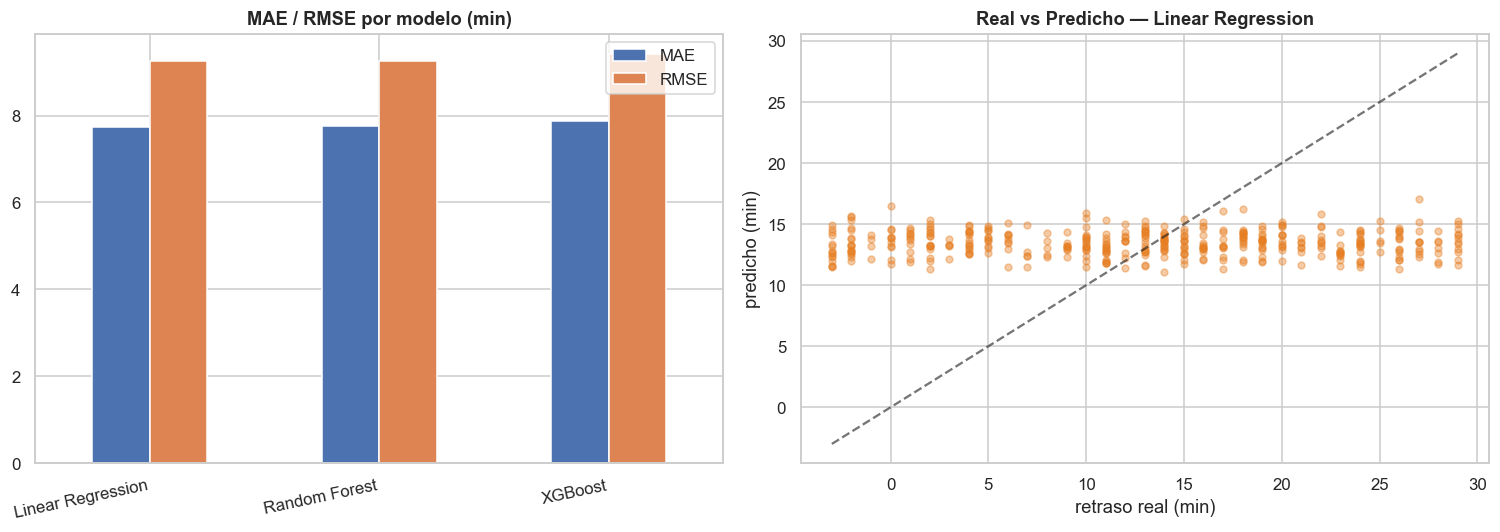

In [3]:
best=tab["MAE"].idxmin(); print("🏆 Mejor modelo (menor MAE):",best)
mdl=modelos[best]; p_best=preds[best]

fig,ax=plt.subplots(1,2,figsize=(14,5))
tab[["MAE","RMSE"]].plot.bar(ax=ax[0]); ax[0].set_title("MAE / RMSE por modelo (min)")
ax[0].set_xticklabels(tab.index,rotation=12,ha="right")
ax[1].scatter(yte,p_best,alpha=.4,color="#E67E22",s=20)
lim=[min(yte.min(),p_best.min()),max(yte.max(),p_best.max())]
ax[1].plot(lim,lim,"k--",alpha=.6); ax[1].set_title(f"Real vs Predicho — {best}")
ax[1].set_xlabel("retraso real (min)"); ax[1].set_ylabel("predicho (min)")
fig.tight_layout(); fig.savefig(REPORTS/"06_model_comparison.png", bbox_inches="tight")
fig.savefig(REPORTS/"07_predictions.png", bbox_inches="tight"); plt.show()

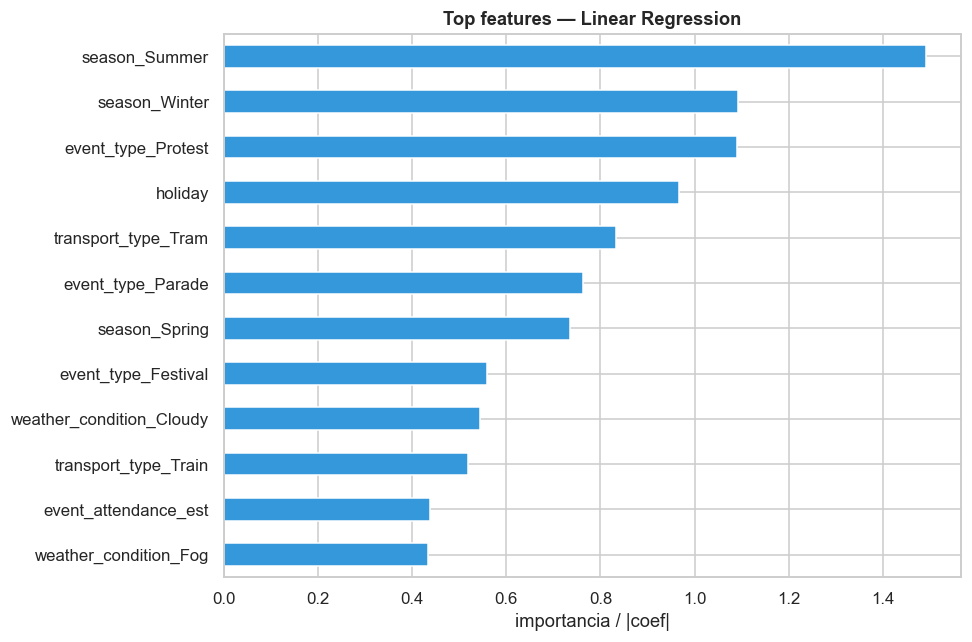

Top 5: ['season_Summer', 'season_Winter', 'event_type_Protest', 'holiday', 'transport_type_Tram']


In [4]:
if hasattr(mdl,"feature_importances_"):
    imp=pd.Series(mdl.feature_importances_,index=FEATURES)
else:
    imp=pd.Series(np.abs(mdl.coef_),index=FEATURES)
top=imp.sort_values(ascending=False).head(12)
fig,ax=plt.subplots(figsize=(9,6)); top[::-1].plot.barh(ax=ax,color="#3498db")
ax.set_title(f"Top features — {best}"); ax.set_xlabel("importancia / |coef|")
fig.tight_layout(); fig.savefig(REPORTS/"08_feature_importance.png", bbox_inches="tight"); plt.show()
print("Top 5:",list(top.head(5).index))

## 3.3 Serialización + interpretación de negocio

In [5]:
pickle.dump({"model":mdl,"model_name":best,"features":FEATURES,
             "scaler":S["scaler"],"cols_scaled":S["cols_scaled"]}, open(SRC/"best_model.pkl","wb"))
metrics={"best_model":best,
         "comparison":{k:{kk:round(vv,3) for kk,vv in v.items()} for k,v in res.items()}}
json.dump(metrics, open(REPORTS/"metrics.json","w",encoding="utf-8"), indent=2, ensure_ascii=False)
print("Modelo y metrics.json guardados.")
print(f"\nInterpretación: el mejor modelo logra R²={res[best]['R2']:.3f} y MAE={res[best]['MAE']:.2f} min.")
print("Un R² bajo indica que las features disponibles (clima/eventos sintéticos) explican poco")
print("la variabilidad del retraso — hallazgo honesto del dataset, no un fallo del pipeline.")

Modelo y metrics.json guardados.

Interpretación: el mejor modelo logra R²=-0.016 y MAE=7.73 min.
Un R² bajo indica que las features disponibles (clima/eventos sintéticos) explican poco
la variabilidad del retraso — hallazgo honesto del dataset, no un fallo del pipeline.


## Conclusiones

- Con un dataset pequeño (2,000) y **features de baja señal**, los modelos logran un **R² bajo**:
  el clima y los eventos sintéticos explican poco el retraso. Es un resultado válido y honesto.
- La **validación cruzada** confirma que el resultado no es un artefacto de un único split.
- El **MAE en minutos** es la métrica más interpretable para operación.
- Próximo paso real: conseguir datos con mayor señal (GPS, incidencias, ocupación) — sin mejores
  features, ningún algoritmo rescatará la predicción.